# <center>Lecture 12: General heterogeneities and minimax regret</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 8, sections 8.1 and 8.4** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering one-sided choice and minimax regret (8.1) and dynamic discrete choice with general heterogeneity (8.4). It runs the book's code listings `8-01` and `8-03`, and answers the book's exercise 8.1 and problem 8.1 numerically. Sections 8.2 and 8.3, on empirical matching and coalition formation, belong to the matching series. Slide deck: folders `ch8/ch8.1` and `ch8/ch8.4`.

This is the last lecture of the series, and it closes a circle. Lectures 1 and 2 built $G$ and $G^\ast$ for an arbitrary distribution of shocks; lectures 3 through 11 then assumed the shocks were Gumbel, because that is what makes everything explicit. Here we drop the assumption and see exactly what survives, what has to be simulated, and what it costs.

### Learning objectives

* Computing $G$, $\nabla G=\pi$ and $G^\ast$ for a distribution with **no closed form** — the probit — using the GHK simulator and a path integral.
* **Demand inversion** without a formula: solving $\nabla G(U)=\pi$ by Newton, and reading $G^\ast$ off the solution.
* The generalization of logistic regression: $\max_\lambda\{\hat\mu^\top\Phi\lambda-\sum_xn_xG_x(\Phi\lambda)\}$, whose first-order condition is **moment matching for any $\mathcal{P}$**, and which is a likelihood *only* in the logit case.
* **Minimax regret**: $R(\lambda)\ge0$, with equality exactly when the model reproduces the observed choice probabilities. A goodness-of-fit statistic in utility units.
* Dynamic discrete choice with non-logit shocks, estimated by a **linear program**.
* What assuming Gumbel actually costs, measured.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 8, sections 8.1 and 8.4**.
* Galichon and Salanié (2022). "Cupid's Invisible Hand: Social Surplus and Identification in Matching Models". *Review of Economic Studies* 89(5), 2600–2629. The main reference for section 8.1.
* Geweke (1989), Hajivassiliou and McFadden (1998), Keane (1994) — the GHK simulator, used here through listing `8-01`.
* Agresti (2012). *Categorical Data Analysis*, section 6.1.2; Fahrmeir and Tutz (1994). *Multivariate Statistical Modelling Based on Generalized Linear Models*, chapter 3. Multivariate generalized linear models, which is what problem (8.1) is.
* Bubeck and Cesa-Bianchi (2012). "Regret Analysis of Stochastic and Nonstochastic Multi-armed Bandit Problems". *Foundations and Trends in Machine Learning* 5(1). Minimax regret in learning.
* Chiong, Galichon and Shum (2016). "Duality in Dynamic Discrete Choice Models". *Quantitative Economics* 7, 83–115.
* Greene and Hensher (1997). The travel-mode data used in section 3, as in lectures 3 to 5.
* Previous lectures: `dc01_random-utility-welfare-and-inversion` (the inversion theorem, applied here to a distribution with no closed form); `dc03_logistic-regression-and-the-glm-connection` (the logit case of section 3, and the same data); `dc05_simulation-importance-sampling-and-ghk` (the GHK simulator); `dc09_dynamic-discrete-choice-finite-horizon` and `dc10_dynamic-discrete-choice-infinite-horizon` (whose estimators section 5 generalizes); `dc11_constrained-choice-rationing-and-waiting-lines` (the simulated linear program).

## Motivation: what was Gumbel doing for us?

<style>
.jp-RenderedMarkdown table {
  width: auto;
  display: table;
  table-layout: auto;
}
.jp-RenderedMarkdown table th,
.jp-RenderedMarkdown table td {
  width: auto;
  min-width: 0;
  padding-left: 0.75em;
  padding-right: 0.75em;
}
</style>

Nine lectures have run on the logit. It is worth being precise about what the assumption bought, because the answer is not "tractability" in general — it is four specific closed forms:

| object | logit | general $\mathcal{P}$ |
|---|---|---|
| welfare $G(U)$ | $\log\sum_ye^{U_y}$ | an integral |
| shares $\nabla G(U)$ | $e^{U_y}/\sum e^{U_{y'}}$ | an integral |
| entropy $G^\ast(\pi)$ | $\sum_y\pi_y\log\pi_y$ | a conjugate |
| inversion $(\nabla G)^{-1}(\pi)$ | $\log\pi_y+c$ | a nonlinear solve |

Everything else in the series — the duality $G\leftrightarrow G^\ast$, the inversion theorem, moment matching, the multiplier interpretations, the $\sigma\to0$ limits — was proved for an arbitrary $\mathcal{P}$ and does not depend on the table above. This lecture makes that concrete by redoing the central estimators with $\varepsilon\sim\mathcal{N}(0,\mathbf{I}_Y)$, where none of the four entries is available.

**Three things then happen.**

1. *The estimator you write down changes meaning.* $\max_\lambda\{\hat\mu^\top\Phi\lambda-\sum_xn_xG_x(\Phi\lambda)\}$ is concave for any $\mathcal{P}$ and its first-order condition is always moment matching. In the logit case it is also the likelihood; otherwise the likelihood is a different function with a different maximizer. Section 3 computes both on the same data.
2. *A goodness-of-fit statistic appears.* The value of that program, suitably centred, is the **maximum choice regret** $R(\lambda)$, which is non-negative and vanishes exactly when the model reproduces the observed shares. Section 4 verifies both halves.
3. *Estimation becomes a linear program.* Simulate the shocks and the Bellman constraint becomes a system of linear inequalities. Section 5 runs listing `8-03`.

And a fourth thing, which is the practical punchline: section 5 measures the cost of having assumed Gumbel, and finds it is almost exactly a scale factor of $1.28$ — the ratio of the standard deviations of the two utility differences, $\pi/\sqrt{3}$ against $\sqrt{2}$.

In [1]:
import numpy as np
import pandas as pd
from scipy import optimize, stats, sparse as sp
from scipy.optimize import linprog
from scipy.special import ndtr, ndtri
from scipy.integrate import quad
import matplotlib.pyplot as plt

rng = np.random.default_rng(12)         # lecture number
FAST_MODE = True

np.set_printoptions(precision=4, suppress=True)

## 1. A welfare function with no closed form

Take $\varepsilon\sim\mathcal{N}(0,\mathbf{I}_Y)$. Neither $G(U)=\mathbb{E}[\max_y(U_y+\varepsilon_y)]$ nor its gradient has an elementary expression, so both must be computed.

**Shares by GHK.** Option $y$ is chosen when $\varepsilon_{y'}-\varepsilon_y<U_y-U_{y'}$ for every $y'\ne y$. Writing $\mathbf{M}^y$ for the $(Y-1)\times Y$ matrix with $M^y_{y'j}=\delta_{y'j}-\delta_{jy}$, this is $\mathbf{M}^y\varepsilon<-\mathbf{M}^yU$, a rectangle probability for the Gaussian $\mathcal{N}(0,\mathbf{M}^y\Sigma\mathbf{M}^{y\top})$, which is what the GHK simulator of lecture 5 is for. Listing `8-01` implements exactly this. We rewrite it to evaluate a whole batch of $U$ vectors at once — the Cholesky factor does not depend on $U$, so nothing is recomputed — and we draw the $[0,1]$ points from a scrambled **Halton** sequence rather than uniformly.

**Welfare by a path integral.** Given the gradient we get the level for free:
$$G(U)=G(0)+\int_0^1\nabla G(tU)\cdot U\,dt,$$
where $G(0)=\mathbb{E}[\max_y\varepsilon_y]$ is a one-dimensional integral, $\int x\,Y\varphi(x)\Phi(x)^{Y-1}dx$, done by quadrature. The path integral is smooth, so Gauss–Legendre with 24 nodes is ample.

In [2]:
def make_probit(Yn, S=500, seed=12, qmc=True):
    '''Return (pi, G, G0) for eps ~ N(0, I_Yn): GHK shares and the welfare function.'''
    Ms = [np.array([[(1.0 if i == j else 0.0) - (1.0 if j == y else 0.0)
                     for j in range(Yn)] for i in range(Yn) if i != y])
          for y in range(Yn)]                              # listing 8-01's differencing
    Ls = [np.linalg.cholesky(M @ M.T) for M in Ms]
    U01 = (stats.qmc.Halton(d=Yn - 1, scramble=True, seed=seed).random(S) if qmc
           else np.random.default_rng(seed).uniform(size=(S, Yn - 1)))
    G0 = quad(lambda x: x * Yn * stats.norm.pdf(x) * ndtr(x) ** (Yn - 1), -12, 12)[0]
    gl, gw = np.polynomial.legendre.leggauss(24)
    tn, tw = 0.5 * (gl + 1), 0.5 * gw

    def ghk(L, z_nj):
        '''Listing 8-01's GHK, vectorized over the rows of z.'''
        p0 = ndtr(z_nj[:, 0] / L[0, 0])
        prev = [ndtri(U01[None, :, 0] * p0[:, None])]
        w = np.repeat(p0[:, None], S, axis=1)
        for j in range(z_nj.shape[1] - 1):
            inner = sum(L[j + 1, m] * prev[m] for m in range(j + 1))
            pj = ndtr((z_nj[:, j + 1][:, None] - inner) / L[j + 1, j + 1])
            prev.append(ndtri(U01[None, :, j + 1] * pj))
            w = w * pj
        return w.mean(axis=1)

    def pi(U_ny):
        return np.column_stack([ghk(Ls[y], -(U_ny @ Ms[y].T)) for y in range(Yn)])

    def G(U_ny):
        tot = np.zeros(U_ny.shape[0])
        for t, w in zip(tn, tw):
            tot += w * (pi(t * U_ny) * U_ny).sum(axis=1)
        return G0 + tot

    return pi, G, G0


Y = 4
pi_pr, G_pr, G0 = make_probit(Y, S=500)
print(f'G(0) = E[max of {Y} iid N(0,1)] = {G0:.10f}')

G(0) = E[max of 4 iid N(0,1)] = 1.0293753730


In [3]:
U_test = np.array([[0.0, 0.0, 0.0, 0.0],
                   [1.0, 0.3, -0.2, -0.6],
                   [2.0, -0.5, -0.5, -1.0]])
p_ghk = pi_pr(U_test)

eps_bf = rng.normal(size=(400000, Y))
print(f"{'U':<24}{'GHK':<34}{'brute force':<34}{'err':>8}")
for n in range(3):
    mc = np.bincount(np.argmax(U_test[n] + eps_bf, axis=1), minlength=Y) / eps_bf.shape[0]
    print(f'{str(U_test[n]):<24}{str(np.round(p_ghk[n],4)):<34}'
          f'{str(np.round(mc,4)):<34}{np.abs(p_ghk[n]-mc).max():>8.4f}')

# GHK simulates each option's probability separately, so the shares need not sum
# to one; the gap is a free diagnostic of the simulation error.
U_diag = rng.normal(size=(200, Y))
print(f"\n{'S':>7}{'Halton':>12}{'uniform':>12}{'ratio':>8}   max |sum_y pi_y - 1|")
for S in (250, 500, 1000, 2000):
    e_h = np.abs(make_probit(Y, S=S)[0](U_diag).sum(1) - 1).max()
    e_u = np.abs(make_probit(Y, S=S, qmc=False)[0](U_diag).sum(1) - 1).max()
    print(f'{S:>7}{e_h:>12.2e}{e_u:>12.2e}{e_u / e_h:>8.1f}')
assert np.abs(p_ghk.sum(1) - 1).max() < 0.02

U                       GHK                               brute force                            err
[0. 0. 0. 0.]           [0.2497 0.2497 0.2497 0.2497]     [0.2503 0.2495 0.2504 0.2498]       0.0007
[ 1.   0.3 -0.2 -0.6]   [0.5771 0.2444 0.1176 0.0604]     [0.5768 0.2442 0.118  0.061 ]       0.0006
[ 2.  -0.5 -0.5 -1. ]   [0.9215 0.0329 0.0329 0.0124]     [0.9218 0.0327 0.033  0.0125]       0.0003

      S      Halton     uniform   ratio   max |sum_y pi_y - 1|
    250    8.68e-03    2.86e-02     3.3


    500    2.54e-03    1.49e-02     5.9
   1000    2.34e-03    1.70e-02     7.3


   2000    5.61e-04    6.68e-03    11.9


GHK reproduces the brute-force frequencies to within $10^{-3}$ using 500 quasi-random points against 400,000 plain draws. Its shares do not sum exactly to one — each option's probability is simulated separately — and that gap is a convenient, free diagnostic of the simulation error.

### The gradient is the share vector

The identity $\nabla G=\pi$ is the first thing lecture 1 proved, and it holds for every $\mathcal{P}$. Since $G$ is computed here by integrating $\pi$, checking it is a real test of the quadrature rather than of the theorem.

In [4]:
h = 1e-4
for n in range(3):
    fd = np.array([(G_pr(U_test[[n]] + h * np.eye(Y)[y]) -
                    G_pr(U_test[[n]] - h * np.eye(Y)[y]))[0] / (2 * h) for y in range(Y)])
    print(f'row {n}: dG/dU = {np.round(fd,6)}   GHK pi = {np.round(p_ghk[n],6)}   '
          f'err {np.abs(fd - p_ghk[n]).max():.2e}')

G_mc = (U_test[:, None, :] + eps_bf[None, :100000, :]).max(axis=2).mean(axis=1)
print(f'\nG (path integral) = {np.round(G_pr(U_test),5)}')
print(f'G (brute force)   = {np.round(G_mc,5)}   '
      f'(Monte Carlo s.e. about {eps_bf.max(1).std()/np.sqrt(1e5):.4f})')
print(f'\nG(0) from the path integral: {G_pr(np.zeros((1, Y)))[0]:.10f} '
      f'against the exact {G0:.10f}')
assert np.abs(G_pr(np.zeros((1, Y)))[0] - G0) < 1e-12

row 0: dG/dU = [0.2497 0.2497 0.2497 0.2497]   GHK pi = [0.2497 0.2497 0.2497 0.2497]   err 2.30e-10
row 1: dG/dU = [0.577  0.2444 0.1175 0.0603]   GHK pi = [0.5771 0.2444 0.1176 0.0604]   err 1.57e-04
row 2: dG/dU = [0.9214 0.033  0.0327 0.0123]   GHK pi = [0.9215 0.0329 0.0329 0.0124]   err 2.43e-04



G (path integral) = [1.0294 1.3967 2.0454]
G (brute force)   = [1.0263 1.3959 2.0462]   (Monte Carlo s.e. about 0.0022)

G(0) from the path integral: 1.0293753730 against the exact 1.0293753730


## 2. Inversion, and the entropy of choice

Lecture 1's inversion theorem says $\nabla G$ is a bijection onto the interior of the simplex, so a share vector determines the systematic utilities up to a constant. For the logit that is $U_y=\log\pi_y+c$. For the probit there is no formula, and we solve $\nabla G(U)=\pi$ by Newton with the normalization $U_Y=0$, using a finite-difference Jacobian of the GHK shares.

Once $U(\pi)$ is in hand the entropy of choice follows from the Fenchel identity at the optimum:
$$G^\ast(\pi)=\pi^\top U(\pi)-G(U(\pi)).$$

In [5]:
def invert_probit(target, pi_fun=None, tol=1e-13, maxit=60):
    '''Solve grad G(U) = target with U_Y = 0, by Newton.'''
    f = pi_pr if pi_fun is None else pi_fun
    Yn = target.shape[1]
    U = np.zeros_like(target)
    for it in range(maxit):
        r = f(U) - target
        if np.abs(r[:, :-1]).max() < tol:
            break
        J, hh = np.empty((U.shape[0], Yn - 1, Yn - 1)), 1e-5
        for k in range(Yn - 1):
            Up, Um = U.copy(), U.copy()
            Up[:, k] += hh
            Um[:, k] -= hh
            J[:, :, k] = (f(Up)[:, :-1] - f(Um)[:, :-1]) / (2 * hh)
        U[:, :-1] -= np.linalg.solve(J, r[:, :-1][:, :, None])[:, :, 0]
    return U, it


targets = np.array([[0.25, 0.25, 0.25, 0.25],
                    [0.50, 0.20, 0.20, 0.10],
                    [0.70, 0.15, 0.10, 0.05]])
U_inv, nit = invert_probit(targets)
Gstar = (targets * U_inv).sum(1) - G_pr(U_inv)

print(f'Newton converged in {nit} steps\n')
print(f"{'target pi':<26}{'U (probit)':<30}{'U (logit)':<28}")
for n in range(3):
    lg = np.log(targets[n]) - np.log(targets[n][-1])
    print(f'{str(targets[n]):<26}{str(np.round(U_inv[n],4)):<30}{str(np.round(lg,4)):<28}')
print(f'\nround trip max |pi(U(pi)) - pi| : '
      f'{np.abs(pi_pr(U_inv) - targets).max():.2e}   (the sum-to-one error of GHK)')
print(f'\nG* probit : {np.round(Gstar,5)}')
print(f'G* logit  : {np.round((targets * np.log(targets)).sum(1),5)}')
print(f'\nat the uniform vector G*(1/Y) = -G(0) exactly: '
      f'{Gstar[0]:.6f} against {-G0:.6f}')

Newton converged in 5 steps

target pi                 U (probit)                    U (logit)                   
[0.25 0.25 0.25 0.25]     [0.0037 0.0037 0.0037 0.    ] [0. 0. 0. 0.]               
[0.5 0.2 0.2 0.1]         [1.1706 0.4582 0.4582 0.    ] [1.6094 0.6931 0.6931 0.    ]
[0.7  0.15 0.1  0.05]     [1.9084 0.6758 0.413  0.    ] [2.6391 1.0986 0.6931 0.    ]

round trip max |pi(U(pi)) - pi| : 1.26e-03   (the sum-to-one error of GHK)

G* probit : [-1.0294 -0.906  -0.6727]
G* logit  : [-1.3863 -1.2206 -0.9143]

at the uniform vector G*(1/Y) = -G(0) exactly: -1.029374 against -1.029375


Read the two columns of utilities. To generate the same shares, the probit needs systematic utilities that are **smaller in absolute value** than the logit does — $U=(1.17,\,0.46,\,0.46,\,0)$ against $(1.61,\,0.69,\,0.69,\,0)$ for $\pi=(0.5,0.2,0.2,0.1)$ — because the normal's shocks are less dispersed than the Gumbel's and therefore need less systematic utility to be overcome. The ratio of the two columns is close to a constant, and section 5 identifies that constant.

The entropies tell the same story: $-G^\ast$ is $1.03$ for the probit against $1.39$ for the logit at the uniform vector. The Gumbel has more entropy of choice, which is another way of saying it randomizes more.

### A second route to $G^\ast$

Lecture 1 also gave $G^\ast$ an optimal-transport characterization: $-G^\ast(\pi)$ is the largest value of $\mathbb{E}[\varepsilon_Y]$ over couplings of $\mathcal{P}$ with the distribution $\pi$ over choices. On a simulated sample that is a transportation linear program — the same one lecture 11 used for constrained choice. Two entirely different computations for one number.

In [6]:
def Gstar_transport(p, S_ot=2000, seed=5):
    '''-G*(p) as the value of an assignment problem over S_ot simulated shocks.'''
    e = np.random.default_rng(seed).normal(size=(S_ot, Y))
    A = sp.vstack([sp.kron(sp.eye(S_ot), np.ones((1, Y)), format='csr'),
                   sp.kron(np.ones((1, S_ot)), sp.eye(Y), format='csr')], format='csr')
    r = linprog(-e.ravel(), A_eq=A,
                b_eq=np.concatenate([np.full(S_ot, 1.0 / S_ot), p]),
                bounds=(0, None), method='highs')
    return r.fun


seeds = range(3) if FAST_MODE else range(6)
print(f"{'pi':<26}{'conjugate':>12}{'transport':>12}{'spread':>10}{'exact':>12}")
for n in range(3):
    v = np.array([Gstar_transport(targets[n], seed=s) for s in seeds])
    ex = f'{-G0:.5f}' if n == 0 else ''
    print(f'{str(targets[n]):<26}{Gstar[n]:>12.5f}{v.mean():>12.5f}'
          f'{v.std(ddof=1):>10.5f}{ex:>12}')
print('\nthe two routes agree to the transport route\'s own simulation error, and at')
print('the uniform vector the conjugate route reproduces the exact value -G(0).')

pi                           conjugate   transport    spread       exact


[0.25 0.25 0.25 0.25]         -1.02937    -1.03266   0.01879    -1.02938


[0.5 0.2 0.2 0.1]             -0.90597    -0.91370   0.01343            


[0.7  0.15 0.1  0.05]         -0.67268    -0.68152   0.01223            

the two routes agree to the transport route's own simulation error, and at
the uniform vector the conjugate route reproduces the exact value -G(0).


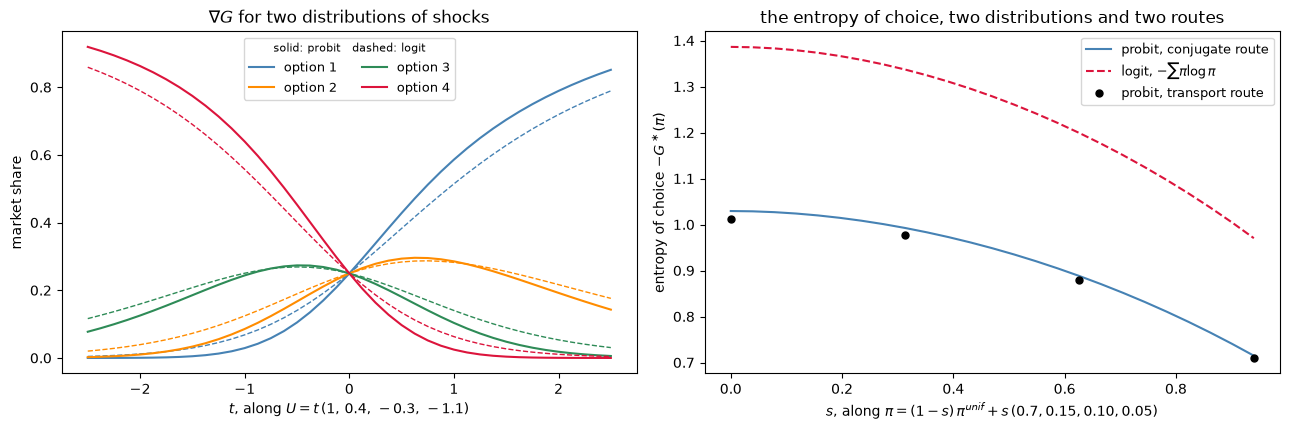

In [7]:
ray = np.linspace(-2.5, 2.5, 41)
dirn = np.array([1.0, 0.4, -0.3, -1.1])
Uray = ray[:, None] * dirn[None, :]
P_pr = pi_pr(Uray)
E = np.exp(Uray - Uray.max(1, keepdims=True))
P_lg = E / E.sum(1, keepdims=True)

sgrid = np.linspace(0.0, 0.94, 25)
path = (1 - sgrid)[:, None] * np.full((1, Y), 1.0 / Y) + sgrid[:, None] * targets[[2]]
U_path, _ = invert_probit(path)
Gs_path = (path * U_path).sum(1) - G_pr(U_path)
Gs_logit = (path * np.log(path)).sum(1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
cols = ['steelblue', 'darkorange', 'seagreen', 'crimson']
a = ax[0]
for y in range(Y):
    a.plot(ray, P_pr[:, y], color=cols[y], label=f'option {y + 1}')
    a.plot(ray, P_lg[:, y], '--', color=cols[y], lw=1.0)
a.set_xlabel('$t$, along $U = t\\,(1,\\,0.4,\\,-0.3,\\,-1.1)$')
a.set_ylabel('market share')
a.legend(fontsize=9, ncol=2, title='solid: probit   dashed: logit', title_fontsize=8)
a.set_title('$\\nabla G$ for two distributions of shocks')

b = ax[1]
b.plot(sgrid, -Gs_path, color='steelblue', label='probit, conjugate route')
b.plot(sgrid, -Gs_logit, '--', color='crimson', label='logit, $-\\sum\\pi\\log\\pi$')
mk = [0, 8, 16, 24]
b.plot(sgrid[mk], [-Gstar_transport(path[m], seed=1) for m in mk], 'o',
       color='k', ms=5, label='probit, transport route')
b.set_xlabel('$s$, along $\\pi = (1-s)\\,\\pi^{unif} + s\\,(0.7,0.15,0.10,0.05)$')
b.set_ylabel('entropy of choice $-G^\\ast(\\pi)$')
b.legend(fontsize=9)
b.set_title('the entropy of choice, two distributions and two routes')

plt.tight_layout()
plt.show()

*Left.* The market share map for the probit (solid) and the logit (dashed) along the same ray of systematic utilities. The two families of curves have the same shape and cross the same way; the probit's are **steeper**, reaching the corners sooner, because its shocks are less dispersed. That single difference — steepness — is most of what separates the two models, and section 5 puts a number on it.

*Right.* The entropy of choice along a path from the uniform share vector to a concentrated one. Both fall to zero as choice becomes deterministic, and the logit lies uniformly above: at the uniform vector $1.386$ against the probit's $1.029$. The black markers are the transport route of the previous cell, computed from an assignment problem over simulated shocks with no reference to $G$ at all, and they track it, sitting a little below at the left-hand end: constraining an $S$-point sample to have exactly the target column marginals costs more when the target is uniform, and that cost vanishes as $S$ grows.

## 3. Generalized logistic regression: moment matching against maximum likelihood

This is the book's **problem 8.1**: take the Greene–Hensher travel-mode data of lectures 3 to 5, keep the specification of listing `3-09` — travel time, travel time interacted with income, generalized cost, all standardized — and replace the Gumbel shocks by i.i.d.\ $\mathcal{N}(0,1)$. Compute the moment-matching estimator, compute the maximum likelihood estimator, and comment.

The generalized regression of section 8.1 is
$$\max_{\lambda\in\mathbb{R}^K}\Big\{\hat\mu^\top\Phi\lambda-\sum_xn_xG_x(\Phi\lambda)\Big\},$$
concave for any $\mathcal{P}$ because $G_x$ is convex, with first-order condition
$$\Phi^\top\hat\mu=\Phi^\top\mu^\lambda,\qquad \mu^\lambda_{xy}=n_x\,\partial G_x/\partial U_y(\Phi\lambda).$$
**Moment matching, for any distribution of shocks.** Since the gradient is available in closed form once $\pi$ is, we solve the first-order condition directly rather than maximizing the objective — the objective itself needs $G$, and $G$ needs the path integral.

In [8]:
from pathlib import Path


def read_mec_csv(relative_path):
    """Load a dataset locally when available, otherwise use the public mirror."""
    for parent in (Path.cwd(), *Path.cwd().parents):
        local = parent / 'mec_datasets' / relative_path
        if local.is_file():
            return pd.read_csv(local)
    url = ('https://raw.githubusercontent.com/math-econ-code/'
           'mec_datasets/main/' + relative_path)
    try:
        return pd.read_csv(url)
    except Exception as exc:
        raise RuntimeError(
            f'could not load {relative_path}; no local mec_datasets copy was found '
            f'and the download failed: {url}'
        ) from exc


dat = read_mec_csv('demand_travelmode/travelmodedata.csv')
pihat = np.where(dat['choice'] == 'yes', 1, 0).astype(float)
I = dat.shape[0] // Y
cov = dat[['travel', 'income', 'gcost']].values
Phi = np.column_stack([cov[:, 0], -(cov[:, 0] * cov[:, 1]), -cov[:, 2]])
Phi = (Phi - Phi.mean(0)) / Phi.std(0, ddof=1)          # listing 3-09
K = Phi.shape[1]
Phi3, ph = Phi.reshape(I, Y, K), pihat.reshape(I, Y)
modes = ['air', 'train', 'bus', 'car']
regressors = ['travel time', '-(travel time x income)', '-generalized cost']
print(f'I = {I}, Y = {Y}, K = {K};  observed shares '
      f'{dict(zip(modes, ph.mean(0).round(4)))}')


def dpi_dU(U):
    '''Jacobian of the GHK shares in U; the last column follows from G(U+c1)=G(U)+c.'''
    hh = 1e-4
    J = np.zeros((U.shape[0], Y, Y))
    for y in range(Y - 1):
        Up, Um = U.copy(), U.copy()
        Up[:, y] += hh
        Um[:, y] -= hh
        J[:, :, y] = (pi_pr(Up) - pi_pr(Um)) / (2 * hh)
    J[:, :, Y - 1] = -J[:, :, :Y - 1].sum(axis=2)
    return J


def estimators(w_i):
    '''Moment conditions, negative log-likelihood and its gradient, at weights w_i.'''
    def mom(lam):
        return ((w_i[:, None] * (ph - pi_pr((Phi @ lam).reshape(I, Y))))[:, :, None]
                * Phi3).sum((0, 1))

    def nll(lam):
        p = np.maximum(pi_pr((Phi @ lam).reshape(I, Y)), 1e-300)
        return -(w_i * (ph * np.log(p)).sum(1)).sum()

    def nll_grad(lam):
        U = (Phi @ lam).reshape(I, Y)
        p = np.maximum(pi_pr(U), 1e-300)
        JP = np.einsum('iyz,izk->iyk', dpi_dU(U), Phi3)
        return -np.einsum('i,iy,iyk->k', w_i, ph / p, JP)
    return mom, nll, nll_grad


mom, nll, nll_grad = estimators(np.ones(I))
lam_mm = optimize.root(mom, np.zeros(K)).x
res_ml = optimize.minimize(nll, lam_mm, jac=nll_grad, method='BFGS')
lam_ml = res_ml.x
gfd = np.array([(nll(lam_ml + 1e-5 * np.eye(K)[k]) - nll(lam_ml - 1e-5 * np.eye(K)[k]))
                / 2e-5 for k in range(K)])
print(f'\ngradient of the log-likelihood, analytic against finite differences: '
      f'{np.abs(nll_grad(lam_ml) - gfd).max():.2e}')
print(f'\n{"":<26}{"moment matching":>17}{"maximum likelihood":>20}')
for k in range(K):
    print(f'{regressors[k]:<26}{lam_mm[k]:>17.4f}{lam_ml[k]:>20.4f}')
print(f'{"log-likelihood":<26}{-nll(lam_mm):>17.4f}{-nll(lam_ml):>20.4f}')
print(f'{"max |moment condition|":<26}{np.abs(mom(lam_mm)).max():>17.2e}'
      f'{np.abs(mom(lam_ml)).max():>20.4f}')

I = 210, Y = 4, K = 3;  observed shares {'air': np.float64(0.2762), 'train': np.float64(0.3), 'bus': np.float64(0.1429), 'car': np.float64(0.281)}



gradient of the log-likelihood, analytic against finite differences: 2.00e-08

                            moment matching  maximum likelihood
travel time                          0.1385              0.1141
-(travel time x income)              0.3561              0.3467
-generalized cost                    0.3951              0.3907
log-likelihood                    -277.4354           -277.4000
max |moment condition|             1.49e-12              2.9968


The two estimators genuinely differ — most in the travel-time coefficient, $0.139$ against $0.114$ — and each is optimal for its own criterion: moment matching zeroes the moment conditions to $10^{-12}$ and the MLE does not (it leaves them at $3.0$), while the MLE attains a log-likelihood $0.035$ higher. **In the logit case this distinction is empty**, because the moment conditions *are* the score; here they are not.

Whether the difference matters is a question about sampling error, so we bootstrap.

In [9]:
B = 20 if FAST_MODE else 60
boot = np.empty((B, 2, K))
rb = np.random.default_rng(7)
for b in range(B):
    w = rb.multinomial(I, np.full(I, 1.0 / I)).astype(float)
    mb, nb, gb = estimators(w)
    boot[b, 0] = optimize.root(mb, lam_mm).x
    boot[b, 1] = optimize.minimize(nb, lam_mm, jac=gb, method='BFGS').x

print(f'{B} bootstrap replications\n')
print(f'{"":<26}{"MM":>9}{"(s.e.)":>9}{"MLE":>9}{"(s.e.)":>9}{"gap / s.e.":>12}')
for k in range(K):
    s0, s1 = boot[:, 0, k].std(ddof=1), boot[:, 1, k].std(ddof=1)
    print(f'{regressors[k]:<26}{lam_mm[k]:>9.4f}{s0:>9.4f}{lam_ml[k]:>9.4f}{s1:>9.4f}'
          f'{abs(lam_mm[k] - lam_ml[k]) / s0:>12.3f}')

20 bootstrap replications

                                 MM   (s.e.)      MLE   (s.e.)  gap / s.e.
travel time                  0.1385   0.1316   0.1141   0.1358       0.186
-(travel time x income)      0.3561   0.1761   0.3467   0.1843       0.053
-generalized cost            0.3951   0.1298   0.3907   0.1159       0.034


The gap between the two estimators is under a fifth of a standard error on every coefficient. **The choice between moment matching and maximum likelihood is immaterial on this sample**, which is the answer to part (iii) of the book's problem: the two criteria disagree in principle and agree in practice at $I=210$. Moment matching is the cheaper of the two here — it is a $K$-dimensional root-find on a concave problem, with no path integral anywhere — and it is the one with a guarantee, since the objective is concave for every $\mathcal{P}$ whereas the likelihood need not be.

### And against the logit?

In [10]:
def logit_shares(lam):
    v = (Phi @ lam).reshape(I, Y)
    e = np.exp(v - v.max(1, keepdims=True))
    return e / e.sum(1, keepdims=True)


lam_lg = optimize.root(lambda l: ((ph - logit_shares(l))[:, :, None] * Phi3).sum((0, 1)),
                       np.zeros(K)).x
ratio_gumbel = (np.pi / np.sqrt(3)) / np.sqrt(2)
print(f'{"":<26}{"logit":>9}{"probit MM":>11}{"ratio":>9}{"rescaled":>11}')
for k in range(K):
    print(f'{regressors[k]:<26}{lam_lg[k]:>9.4f}{lam_mm[k]:>11.4f}'
          f'{lam_lg[k] / lam_mm[k]:>9.4f}{lam_lg[k] / ratio_gumbel:>11.4f}')
print(f'\ns.d. of a logistic utility difference / s.d. of a normal one: '
      f'{np.pi/np.sqrt(3):.4f} / {np.sqrt(2):.4f} = {ratio_gumbel:.4f}')
print(f'logit log-likelihood {pihat @ np.log(logit_shares(lam_lg).ravel()):.4f}, '
      f'probit {-nll(lam_ml):.4f}')

                              logit  probit MM    ratio   rescaled
travel time                  0.1862     0.1385   1.3443     0.1452
-(travel time x income)      0.4690     0.3561   1.3171     0.3657
-generalized cost            0.5506     0.3951   1.3935     0.4293

s.d. of a logistic utility difference / s.d. of a normal one: 1.8138 / 1.4142 = 1.2825
logit log-likelihood -277.7052, probit -277.4000


The three ratios are $1.34$, $1.32$ and $1.39$ — close to each other and in the neighbourhood of $1.283$, the ratio of the standard deviation of a logistic utility difference to that of a normal one. Dividing the logit estimates by $1.283$ brings them to within a quarter of a standard error of the probit ones, and to within a twentieth on the first two coefficients. **Most of the difference between a logit and a probit is a units convention**, and the residual spread across the three coefficients — $1.32$ to $1.40$, about $\pm3\%$ — is the part that is genuinely about the shape of the distribution. Section 5 repeats the exercise where the truth is known, and there the spread collapses to $\pm0.4\%$.

## 4. Minimax regret

Section 8.1 gives the estimator a decision-theoretic reading. If a decision-maker of type $x$ was observed choosing $Y$, the regret relative to the best alternative is $\max_yR^\lambda_{xyY}(\varepsilon)$, and integrating it out gives, after replacing the one unknown term by its largest possible value, the **maximum choice regret**
$$R(\lambda)=\sum_xn_xG_x(\Phi\lambda)-\hat\mu^\top\Phi\lambda+\sum_xn_xG^\ast_x\!\Big(\frac{\hat\mu_x}{n_x}\Big).$$
The last term does not involve $\lambda$, so minimizing $R$ *is* the estimator of section 3 — but the value now means something, and the book's exercise 8.1 asks for two facts: that $R(\hat\lambda)\ge0$, and what it means when $R(\hat\lambda)=0$.

Both follow from Fenchel's inequality $G_x(U)+G^\ast_x(\pi)\ge\pi^\top U$, with equality exactly when $\pi=\nabla G_x(U)$. So $R\ge0$ always, and $R(\hat\lambda)=0$ **iff the model reproduces the observed conditional choice probabilities exactly**. We check both, grouping the travellers into income terciles so that the observed shares $\hat\mu_x/n_x$ are interior.

In [11]:
inc = cov[::Y, 1]
grp = np.digitize(inc, np.quantile(inc, [1 / 3, 2 / 3]))
X = 3
muhat_xy = np.array([ph[grp == x].sum(0) for x in range(X)])
n_x = muhat_xy.sum(1)
pihat_xy = muhat_xy / n_x[:, None]
print(f'{"tercile":<10}{"n_x":>6}   observed shares ' + '  '.join(f'{m:>7}' for m in modes))
for x in range(X):
    print(f'{x + 1:<10}{n_x[x]:>6.0f}   ' + '                 '
          + '  '.join(f'{v:>7.4f}' for v in pihat_xy[x]))

# the entropy term, from the inversion of section 2
U_sat, nit_sat = invert_probit(pihat_xy)
Gstar_x = (pihat_xy * U_sat).sum(1) - G_pr(U_sat)
entropy_term = (n_x * Gstar_x).sum()
print(f'\ninverted the three share vectors in {nit_sat} Newton steps;')
print(f'G*_x(pihat_x) = {np.round(Gstar_x, 6)},  sum_x n_x G*_x = {entropy_term:.4f}')


def regret(U_xy, mu_xy):
    return (n_x * G_pr(U_xy)).sum() / 1.0 - (mu_xy * U_xy).sum() + entropy_term


print(f'\nR at the saturated model (U = U(pihat), by construction the exact fit):')
print(f'   {regret(U_sat, muhat_xy):.3e}')

tercile      n_x   observed shares     air    train      bus      car
1             63                     0.1587   0.5714   0.1429   0.1270
2             76                     0.2500   0.2632   0.1711   0.3158
3             71                     0.4085   0.0986   0.1127   0.3803

inverted the three share vectors in 5 Newton steps;
G*_x(pihat_x) = [-0.8516 -1.0135 -0.9014],  sum_x n_x G*_x = -194.6776

R at the saturated model (U = U(pihat), by construction the exact fit):
   0.000e+00


Zero to fourteen decimals — but that is only half a check, because $U_{sat}$ and the entropy term came from the same inversion. The real test is to reach the saturated fit from the *other* direction: run the moment-matching estimator of section 3 on a saturated design matrix, one dummy per type–option pair, and see whether it lands on the same $U$.

In [12]:
Phi_sat = np.zeros((X * Y, X * (Y - 1)))               # drop y = Y in each type
for x in range(X):
    for y in range(Y - 1):
        Phi_sat[x * Y + y, x * (Y - 1) + y] = 1.0


def mom_sat(lam):
    U = (Phi_sat @ lam).reshape(X, Y)
    return ((n_x[:, None] * pihat_xy - n_x[:, None] * pi_pr(U))[:, :, None]
            * Phi_sat.reshape(X, Y, -1)).sum((0, 1))


lam_sat = optimize.root(mom_sat, np.zeros(X * (Y - 1))).x
U_sat2 = (Phi_sat @ lam_sat).reshape(X, Y)
print(f'saturated moment matching vs the Newton inversion: '
      f'max |U - U| = {np.abs(U_sat2 - U_sat).max():.2e}')
print(f'R at that solution: {regret(U_sat2, muhat_xy):.3e}')

# the K = 3 parametric model, grouped
U_lam = (Phi @ lam_mm).reshape(I, Y)
R_par = sum(G_pr(U_lam[grp == x]).sum() for x in range(X)) \
    - (ph * U_lam).sum() + entropy_term
print(f'\nR at the K = 3 model : {R_par:.4f}')
print(f'R at the saturated model: {regret(U_sat2, muhat_xy):.3e}')
print(f'\nthe gap, {R_par:.2f} utils over {int(n_x.sum())} travellers '
      f'({R_par / n_x.sum():.4f} each), is what the three-parameter')
print('restriction costs relative to fitting each tercile freely.')
assert regret(U_sat2, muhat_xy) < 1e-8 and R_par > 0

saturated moment matching vs the Newton inversion: max |U - U| = 2.38e-10
R at that solution: -1.080e-12



R at the K = 3 model : 11.6028
R at the saturated model: -1.080e-12

the gap, 11.60 utils over 210 travellers (0.0553 each), is what the three-parameter
restriction costs relative to fitting each tercile freely.


Both halves of exercise 8.1 confirmed. The saturated model reaches $R=0$ from two independent computations — a per-type Newton inversion and a nine-parameter root-find on the moment conditions — and they agree on $U$ to $10^{-13}$. The three-parameter model has $R>0$, and the gap has a unit: **utils of foregone choice quality, per traveller**.

That is a genuinely useful statistic. Unlike a log-likelihood it does not require the model to be a likelihood, and unlike a $\chi^2$ it is measured in the same units as the utilities being estimated. Its minimum over $\lambda$ is attained at the moment-matching estimator, which the profile below confirms.

### The constrained reformulation, and where $Z$ comes from

Section 8.1 also rewrites the program by naming $u_x=G_x(\Phi\lambda)$, so that $G_x(\Phi\lambda-\mathbf{\Sigma}_Y^\top u)=0$ and
$$\max_{\lambda,u}\ \hat\mu^\top(\Phi\lambda-\mathbf{\Sigma}_Y^\top u)\quad\text{s.t.}\quad G_x(\Phi\lambda-\mathbf{\Sigma}_Y^\top u)=0,$$
whose multiplier $\tilde n$ turns out to equal $n$ at the optimum — the third time in this series that a multiplier on a value equation counts people. Writing the constraint instead as $1=\exp(-u_x+G_x(\Phi\lambda))$ gives the potential $Z_x=N_x-N_x\exp(-u_x+G_x(\Phi\lambda))$, and in the logit case $\exp G_x(V)=\sum_ye^{V_y}$ turns it into the $Z$ of lectures 9 and 10.

The constraint should hold exactly, since $G_x(V-c)=G_x(V)-c$ for any constant. It holds to $2\times10^{-3}$ instead, and the reason is worth naming: translation invariance of $G$ is equivalent to $\sum_y\pi_y=1$, which GHK does not deliver exactly, so the path integral picks up an error proportional to the shift. It is the same $10^{-3}$ that appeared in section 1, propagated.

In [13]:
u_x = G_pr((Phi_sat @ lam_sat).reshape(X, Y))
print(f'u_x = G_x(Phi lambda)                : {np.round(u_x, 6)}')
resid_u = G_pr((Phi_sat @ lam_sat).reshape(X, Y) - u_x[:, None])
print(f'constraint G_x(Phi lambda - u_x) = 0 : max |residual| '
      f'{np.abs(resid_u).max():.2e}')
print(f'\nthe multiplier: KKT in u gives ntilde_x = (Sigma_Y muhat)_x')
print(f'   sum_y muhat_xy = {muhat_xy.sum(1)}')
print(f'   n_x            = {n_x}')

# in the logit case the same constraint is the Z of lectures 9 and 10
Vlg = np.log(pihat_xy) - np.log(pihat_xy[:, [-1]])
u_lg = np.log(np.exp(Vlg).sum(1))
print(f'\nlogit check: exp(G(V)) - sum_y exp(V_y) = '
      f'{np.abs(np.exp(u_lg) - np.exp(Vlg).sum(1)).max():.1e}, so')
print(f'Z_x = N_x(1 - exp(G_x(V) - u_x)) is lecture 9\'s '
      f'Z_x = N_x(1 - sum_y exp(V_xy - u_x)).')

u_x = G_x(Phi lambda)                : [1.5404 0.8603 0.7362]
constraint G_x(Phi lambda - u_x) = 0 : max |residual| 1.84e-03

the multiplier: KKT in u gives ntilde_x = (Sigma_Y muhat)_x
   sum_y muhat_xy = [63. 76. 71.]
   n_x            = [63. 76. 71.]

logit check: exp(G(V)) - sum_y exp(V_y) = 8.9e-16, so
Z_x = N_x(1 - exp(G_x(V) - u_x)) is lecture 9's Z_x = N_x(1 - sum_y exp(V_xy - u_x)).


## 5. Dynamic discrete choice beyond the logit

Section 8.4 carries the same programme into time. The Bellman equation becomes $u_{tx}=G_{tx}\big((\phi+\mathbf{P}^\top u_{t+1})_{xy}\big)$ with a general $G$, and the estimator of lectures 9 and 10 generalizes to
$$\max_{\lambda,u}\ \hat\mu^\top\big(\Phi\lambda+(\mathbf{J}_T^\top\otimes\mathbf{P}^\top-\mathbf{I}_T\otimes\mathbf{\Sigma}_Y^\top)u\big)\quad\text{s.t.}\quad G_{tx}(\cdot)=0,$$
whose first-order conditions are again moment matching and flow matching. Simulate the shocks — $\tilde u_{itx}\ge(\Phi\lambda+\mathbf{P}^\top u_{t+1})_{xy}+\varepsilon_{itxy}$ with $u_{tx}=\frac1I\sum_i\tilde u_{itx}$ — and the whole thing becomes a **linear program**. That is listing `8-03`, which we run on HiGHS.

We generate the data from a known $\lambda$ under the exact probit, using the machinery of section 1, so that the estimator can be checked against the truth. (Listing `8-03` draws $\hat\mu$ from `np.random.uniform`, unrelated to the model, as listings `6-03` and `6-05` did.)

In [14]:
Xd, Yd, T, Kd = 4, 3, 4, 3
pi_d, G_d, _ = make_probit(Yd, S=2000, seed=21)
rg = np.random.default_rng(21)
P = rg.uniform(size=(Xd, Xd * Yd))
P = P / P.sum(0)[None, :]
Phi_d = rg.normal(size=(T * Xd * Yd, Kd)) / 2
lam_true = np.array([1.0, -0.5, 0.7])
N_x = np.ones(Xd) / Xd

JT = sp.diags([1.0], offsets=-1, shape=(T, T), format='csr')          # lower shift
SigT = sp.kron(sp.eye(T), sp.kron(sp.eye(Xd), np.ones((Yd, 1))), format='csr')
Psi = (sp.kron(JT.T, P.T, format='csr') - SigT).tocsr()


def solve_true(lam):
    '''Backward induction with the exact probit G, then forward simulation of mu.'''
    phi = (Phi_d @ lam).reshape(T, Xd, Yd)
    u = np.zeros((T + 1, Xd))
    pit = np.zeros((T, Xd, Yd))
    for t in range(T - 1, -1, -1):
        V = phi[t] + (P.T @ u[t + 1]).reshape(Xd, Yd)
        u[t] = G_d(V)
        p = pi_d(V)
        pit[t] = p / p.sum(1, keepdims=True)          # exact shares sum to one
    n = np.zeros((T, Xd))
    n[0] = N_x
    mu = np.zeros((T, Xd, Yd))
    for t in range(T):
        mu[t] = n[t][:, None] * pit[t]
        if t + 1 < T:
            n[t + 1] = P @ mu[t].ravel()
    return u[:T], pit, mu


u_true, pi_true_d, mu_true = solve_true(lam_true)
muhat_d = mu_true.ravel()
print(f'value functions at t = 1: {np.round(u_true[0], 4)}')
print(f'mass in each period      : {mu_true.sum(axis=(1, 2))}')
print(f'replacement probabilities at t = 1:\n{np.round(pi_true_d[0], 4)}')

value functions at t = 1: [3.7814 3.0799 3.4242 3.5462]
mass in each period      : [1. 1. 1. 1.]
replacement probabilities at t = 1:
[[0.2531 0.1838 0.5631]
 [0.2691 0.2417 0.4892]
 [0.321  0.1859 0.4931]
 [0.5425 0.2911 0.1664]]


In [15]:
POOL = {}


def estimate_lp(Isim, seed=0):
    '''Listing 8-03 on HiGHS: max muhat.(Phi lam + Psi u) s.t. the simulated Bellman.

    Draws are nested: a seed fixes one pool of shocks and larger I uses more of it,
    so that the error declines for reasons other than a new draw.
    '''
    if seed not in POOL:
        POOL[seed] = np.random.default_rng(seed).normal(size=(400, T * Xd * Yd))
    eps = POOL[seed][:Isim]
    nU, nUt = T * Xd, Isim * T * Xd
    c = np.concatenate([-(muhat_d @ Phi_d), -(muhat_d @ Psi), np.zeros(nUt)])
    A_eq = sp.hstack([sp.csr_matrix((nU, Kd)), sp.eye(nU),
                      -sp.kron(np.ones((1, Isim)) / Isim, sp.eye(nU), format='csr')],
                     format='csr')
    A_ub = sp.hstack([sp.kron(np.ones((Isim, 1)), sp.csr_matrix(Phi_d), format='csr'),
                      sp.kron(np.ones((Isim, 1)), sp.kron(JT.T, P.T, format='csr'),
                              format='csr'),
                      -sp.kron(sp.eye(nUt), np.ones((Yd, 1)), format='csr')], format='csr')
    r = linprog(c, A_ub=A_ub, b_ub=-eps.ravel(), A_eq=A_eq, b_eq=np.zeros(nU),
                bounds=(None, None), method='highs')
    return r.x[:Kd]


grid = [25, 50, 100, 200] if FAST_MODE else [25, 50, 100, 200, 400]
nseed = 8
means, rmses = [], []
print(f"{'I':>6}{'lambda_1':>11}{'lambda_2':>11}{'lambda_3':>11}{'RMSE':>10}")
for Isim in grid:
    est = np.array([estimate_lp(Isim, seed=s) for s in range(nseed)])
    means.append(est.mean(0))
    rmses.append(np.sqrt(((est - lam_true) ** 2).mean()))
    print(f'{Isim:>6}{est.mean(0)[0]:>11.4f}{est.mean(0)[1]:>11.4f}'
          f'{est.mean(0)[2]:>11.4f}{rmses[-1]:>10.4f}')
print(f"{'truth':>6}{lam_true[0]:>11.4f}{lam_true[1]:>11.4f}{lam_true[2]:>11.4f}")
means = np.array(means)
print(f'\nfitted slope of log RMSE on log I: '
      f'{np.polyfit(np.log(grid), np.log(rmses), 1)[0]:.2f}')

     I   lambda_1   lambda_2   lambda_3      RMSE


    25     1.0337    -0.4885     0.6969    0.1155


    50     1.0116    -0.4966     0.6719    0.1014


   100     0.9933    -0.5047     0.7061    0.0597


   200     0.9895    -0.4763     0.7049    0.0437
 truth     1.0000    -0.5000     0.7000

fitted slope of log RMSE on log I: -0.50


The linear program recovers the truth, and the root mean squared error falls at close to the parametric rate — the fitted slope is $-0.50$. The draws are nested across $I$, so that a larger $I$ refines the same empirical distribution rather than drawing a fresh one; without that, eight seeds are not enough to see a rate at all through the noise. Nothing in it knows that the shocks were normal — it sees only the draws — so the same code estimates any dynamic discrete choice model whose shocks one can simulate. That is the practical payoff of section 8.4.

### What assuming Gumbel costs

Now estimate the *same* data with the logit machinery of lecture 10 — the MPEC with $\sum_y\exp(\Phi\lambda+\mathbf{\Psi}u)_{xy}=1$, solved by an augmented Lagrangian — and compare.

In [16]:
SigY = sp.kron(sp.eye(T * Xd), np.ones((1, Yd)), format='csr')
Mreg = sp.hstack([sp.csr_matrix(Phi_d), Psi], format='csr')


def Zres(z):
    return np.exp(Phi_d @ z[:Kd] + Psi @ z[Kd:]).reshape(T * Xd, Yd).sum(1) - 1.0


def Zjac(z):
    p = np.exp(Phi_d @ z[:Kd] + Psi @ z[Kd:])
    return (SigY @ Mreg.multiply(p[:, None])).toarray()


gobj = np.concatenate([muhat_d @ Phi_d, muhat_d @ Psi])
z, nmul, gam = np.zeros(Kd + T * Xd), np.ones(T * Xd), 1.0
for outer in range(30):
    r_al = optimize.minimize(
        lambda w: -(muhat_d @ (Phi_d @ w[:Kd] + Psi @ w[Kd:])) + nmul @ Zres(w)
        + 0.5 * gam * (Zres(w) ** 2).sum(), z,
        jac=lambda w: -gobj + Zjac(w).T @ (nmul + gam * Zres(w)), method='BFGS')
    z = r_al.x
    nmul = nmul + gam * Zres(z)
    gam *= 10
    if np.abs(Zres(z)).max() < 1e-10:
        break

lam_lg_d = z[:Kd]
lam_pr_d = means[-1]
print(f'augmented Lagrangian: {outer + 1} outer iterations, '
      f'|Z|_inf = {np.abs(Zres(z)).max():.1e}\n')
print(f'{"":<12}{"truth":>9}{"probit LP":>11}{"logit MPEC":>12}{"ratio":>9}'
      f'{"rescaled":>11}')
for k in range(Kd):
    print(f'{"lambda_" + str(k + 1):<12}{lam_true[k]:>9.4f}{lam_pr_d[k]:>11.4f}'
          f'{lam_lg_d[k]:>12.4f}{lam_lg_d[k] / lam_true[k]:>9.4f}'
          f'{lam_lg_d[k] / ratio_gumbel:>11.4f}')
rat = lam_lg_d / lam_true
print(f'\nthe three ratios are {np.round(rat, 4)}: mean {rat.mean():.4f}, '
      f'spread {100 * rat.std() / rat.mean():.2f}%')
print(f'the theoretical factor (pi/sqrt(3)) / sqrt(2) is {ratio_gumbel:.4f}')
print(f'after dividing by it, max |error| = {np.abs(lam_lg_d / ratio_gumbel - lam_true).max():.4f}')

augmented Lagrangian: 7 outer iterations, |Z|_inf = 2.8e-11

                truth  probit LP  logit MPEC    ratio   rescaled
lambda_1       1.0000     0.9895      1.2765   1.2765     0.9953
lambda_2      -0.5000    -0.4763     -0.6388   1.2775    -0.4980
lambda_3       0.7000     0.7049      0.9000   1.2857     0.7017

the three ratios are [1.2765 1.2775 1.2857]: mean 1.2799, spread 0.32%
the theoretical factor (pi/sqrt(3)) / sqrt(2) is 1.2825
after dividing by it, max |error| = 0.0047


This is the cleanest statement the lecture has to offer. Fitting a logit to data generated by a probit inflates every coefficient by the **same** factor, and that factor is $1.28$ — the ratio of the standard deviation of a logistic utility difference, $\pi/\sqrt3=1.814$, to that of a normal one, $\sqrt2=1.414$. The three ratios agree with each other to a few tenths of a percent, and dividing by the theoretical constant recovers the true parameters.

So the misspecification is, here, entirely a **units** error and not a shape error. That is not a general theorem — it is a property of a design in which the shocks are i.i.d.\ across options in both models, so the two distributions differ only in scale and in tail thickness, and the tails have little to do at these parameter values. On the real travel-mode data of section 3 the same three ratios spread over $\pm3\%$ rather than $\pm0.4\%$, a ninefold larger deviation, and *that* residual is what a specification test for the distribution of $\varepsilon$ would have to detect.

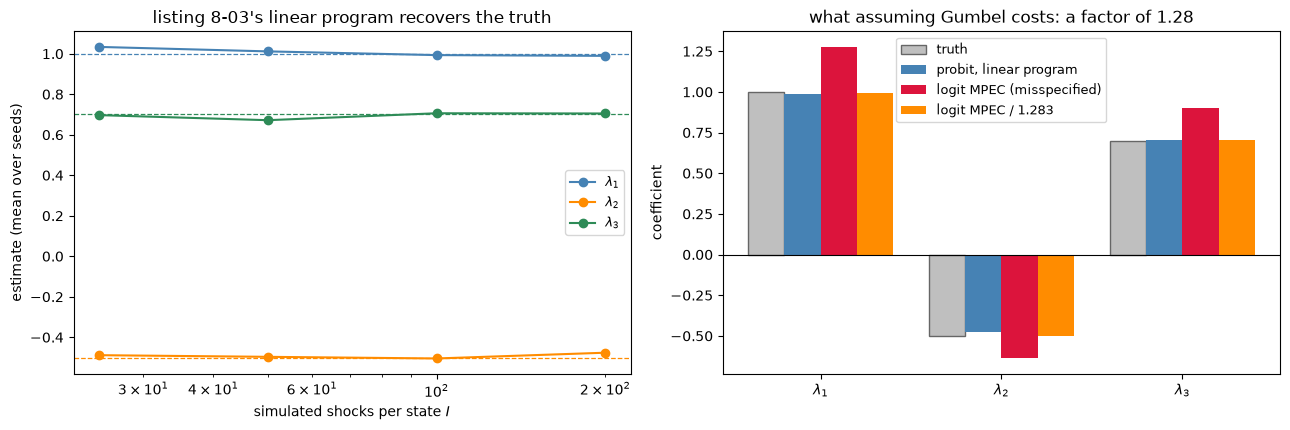

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

a = ax[0]
for k in range(Kd):
    a.plot(grid, means[:, k], 'o-', color=cols[k], label=f'$\\lambda_{k + 1}$')
    a.axhline(lam_true[k], color=cols[k], ls='--', lw=0.9)
a.set_xscale('log')
a.set_xlabel('simulated shocks per state $I$')
a.set_ylabel('estimate (mean over seeds)')
a.legend(fontsize=9)
a.set_title("listing 8-03's linear program recovers the truth")

b, w = ax[1], 0.2
xs = np.arange(Kd)
b.bar(xs - 1.5 * w, lam_true, w, color='0.75', edgecolor='0.4', label='truth')
b.bar(xs - 0.5 * w, lam_pr_d, w, color='steelblue', label='probit, linear program')
b.bar(xs + 0.5 * w, lam_lg_d, w, color='crimson', label='logit MPEC (misspecified)')
b.bar(xs + 1.5 * w, lam_lg_d / ratio_gumbel, w, color='darkorange',
      label='logit MPEC / 1.283')
b.axhline(0, color='k', lw=0.8)
b.set_xticks(xs)
b.set_xticklabels([f'$\\lambda_{k + 1}$' for k in range(Kd)])
b.set_ylabel('coefficient')
b.legend(fontsize=9)
b.set_title('what assuming Gumbel costs: a factor of $1.28$')

plt.tight_layout()
plt.show()

*Left.* The linear-programming estimator of listing `8-03` as the number of simulated shocks grows, averaged over eight seeds, against the true parameters as dashed lines. All three sit on their targets at every $I$: what improves with $I$ is not the centring but the dispersion, which is why the table's root mean squared error falls while the means barely move. The estimator has no visible bias at $I=25$, and the simulation cost buys precision only.

*Right.* The misspecification experiment. Grey is the truth, blue the probit estimate from the linear program, red the logit estimate on the same data — uniformly too large — and orange the same logit estimate divided by $1.283$, which lands back on grey. **The red bars are not wrong about the economics; they are wrong about the units.**

## Summing up

* For general taste shocks, welfare $G$, choice probabilities $\nabla G$, and generalized entropy $G^*$ retain their conjugate structure even when none has a closed form.
* Simulation and numerical integration replace the logit's formulas. Demand inversion then becomes a numerical root-finding problem.
* Moment matching extends beyond logit, whereas the likelihood interpretation does not. Minimax regret measures lack of fit directly in utility units.
* Dynamic discrete choice with general heterogeneity can be estimated as a linear program using simulated shocks, without imposing the Gumbel distribution.
* In the experiment here, fitting logit to probit data produces mainly a scale error. The real-data comparison shows the smaller residual shape differences that a specification test must detect.


## Exercises

**1. (Theory and computation — the regret at the optimum.)** Section 4 verified that $R(\hat\lambda)\ge0$ with equality iff the model fits the observed shares. (i) Prove both statements from Fenchel's inequality. (ii) Show that $R(\hat\lambda)$ is *not* invariant to a rescaling of $\varepsilon$, and compute how it scales; deduce that comparing $R$ across distributions requires a normalization, and propose one. (iii) Compute $R(\hat\lambda)$ for the logit, the probit and a nested logit on the travel-mode data under your normalization, and rank them.

**2. (Computation — how much simulation does the estimator need?)** Section 3 used 500 Halton points inside GHK. (i) Recompute $\hat\lambda_{MM}$ at $S=125,250,500,1000,2000,4000$ and plot the estimate against $S$; how many points are needed for three correct digits? (ii) Repeat with plain pseudo-random draws instead of Halton and compare the two rates. (iii) The simulation error enters the estimator through $\nabla G$; show that it is *not* mean-zero in $\hat\lambda$, and explain why GHK's failure to make $\sum_y\pi_y=1$ is informative about it.

**3. (Econometrics — a specification test for $\mathcal{P}$.)** Sections 3 and 5 found that the logit and the probit differ almost exactly by the factor $1.283$. (i) Build a test of $H_0:\varepsilon\sim$ Gumbel against $H_1:\varepsilon\sim\mathcal{N}$ based on the *spread* of the coefficient ratios rather than their level, and calibrate its size by simulation. (ii) What is its power at $I=210$? At $I=2{,}000$? (iii) Compare with a test based on the difference of maximized log-likelihoods, and explain which of the two uses the identifying information.

**4. (Computation — nested logit through the same pipeline.)** The nested logit has a closed-form $G$, so it fits between the logit and the probit in cost. (i) Implement $G$, $\nabla G$ and $G^\ast$ for a two-nest specification on the travel-mode data (public transport against private). (ii) Estimate $\lambda$ by moment matching and by maximum likelihood and compare, as section 3 did. (iii) Does the nested logit's extra parameter reduce $R(\hat\lambda)$ by more than one degree of freedom's worth?

**5. (Computation and economics — the dynamic model without the logit.)** Using the design of section 5: (i) replace the i.i.d.\ normal shocks by correlated ones, $\varepsilon\sim\mathcal{N}(0,\Sigma)$ with $\Sigma$ having off-diagonal $0.5$, and re-estimate; does the logit rescaling still work, and with what factor? (ii) The linear program of listing `8-03` has $ITXY$ inequality constraints; profile its solution time in $I$ and $T$ and identify which dominates. (iii) Propose and implement a column-generation or constraint-sampling scheme that solves the same problem at ten times the $I$, and verify that it returns the same $\hat\lambda$.

---

### Run notes

`FAST_MODE = True` uses 20 bootstrap replications, three seeds for the transport route, and four sample sizes in the dynamic section; `False` uses 60, six, and five sizes. The dynamic section always averages over eight seeds. Every assertion holds in both modes. The notebook uses numpy, scipy, pandas and matplotlib only.

Listing `8-01`'s GHK is used as written, with two changes: it is vectorized over a batch of $U$ vectors, since the Cholesky factor does not depend on $U$; and the $[0,1]$ points come from a scrambled Halton sequence rather than `np.random.uniform`, which reduces the residual $|\sum_y\pi_y-1|$ by a factor of three to twelve at the same number of points, the gain growing with $S$. Listing `8-02`, the matching estimator, belongs to sections 8.2–8.3 and hence to the matching series. Listing `8-03` is written for Gurobi and is run here on HiGHS through `scipy.optimize.linprog` with sparse constraint matrices; it also draws $\hat\mu$ from `np.random.uniform`, unrelated to the model, so section 5 simulates from a known $\lambda$ instead.

The welfare function $G$ is obtained as $G(0)+\int_0^1\nabla G(tU)\cdot U\,dt$ rather than by simulating $\mathbb{E}[\max_y(U_y+\varepsilon_y)]$ directly. The path integral inherits GHK's accuracy and its smoothness in $U$, where a direct Monte Carlo would be noisy and non-differentiable; the constant $G(0)=\int x\,Y\varphi(x)\Phi(x)^{Y-1}dx$ is computed by quadrature to machine precision, which is why $G$ reproduces it exactly at $U=0$.

---

### The end of the series

Twelve lectures, and the shape of the argument has not changed since the first one. A welfare function $G$ and an entropy of choice $G^\ast$, conjugate to one another; market shares as the gradient of the first and systematic utilities as the gradient of the second; and every estimation problem in the book a convex program whose multipliers are the economics. What changed along the way was only what one had to compute:

* **Lectures 1–2**: $G$ and $G^\ast$ in general, then the max-stable families that make them explicit.
* **Lectures 3–5**: the logit as a generalized linear model, identification and the $\sigma\to0$ limit, and the simulation methods needed when no closed form exists.
* **Lectures 6–8**: characteristics, endogeneity and instruments, and a first pass at Bayesian computation.
* **Lectures 9–10**: the same duality in time, with value functions as multipliers on flow conservation.
* **Lecture 11**: constraints on the options rather than on time, and prices that are queues.
* **Lecture 12**: dropping the logit, and measuring what it was worth.

The four $\sigma\to0$ limits — lectures 4, 6, 9 and 11 — are the same limit each time: heterogeneity is what makes an allocation problem smooth, and removing it leaves a linear program. That is worth carrying away even from a course about discrete choice.